# Stage 9 — Earth model validation and tuning

_Pipeline stage 9 of `docs/PIPELINE_DESIGN.md`. Uses the canonical `channel_heads` package + on-disk artifacts; heavy rebuilds run via the `channel-heads` CLI (see each stage's command)._

## Honest validation + choosing an operating threshold

A single split can be lucky. **Leave-one-basin-out (LOBO)** CV holds out each basin in
turn (the analogue of "apply to a new landscape") and is our honest estimate. We then
pick a decision threshold: F1-optimal maximizes balanced accuracy on Earth, but for
label-free Mars we prefer a **precision-oriented** point (max precision at recall>=0.5).
Run: `python -m channel_heads eval-lobo-cv` / `retune-threshold-regime`.

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import channel_heads as ch
from channel_heads.io.paths import PROJECT_ROOT, RESULTS_DIR, EXAMPLE_DEMS
ROOT     = PROJECT_ROOT
MODELS   = ROOT / 'models'
MARS_OUT = ROOT / 'data/Mars/model_outputs'
MARS_IN  = ROOT / 'data/Mars/model_inputs'
REGIMES_ = ['regA', 'regB', 'regC']
# Frozen model features (5 dimensionless) + operating thresholds (Stage 9).
MODEL_FEATURES = ['orientation_diff_deg','headhead_dist_norm','apex_angle_deg',
                  'strahler_order_diff','proximity_profile_norm']
OP_THR = {'regA': 0.756326, 'regB': 0.779264, 'regC': 0.759369}
print('channel_heads', ch.__version__, '| root', ROOT)


channel_heads 0.1.0 | root /Users/guypi/Projects/channel-heads


### LOBO cross-validation (pooled + per-fold AUC)

,config,n,n_basins,pooled_auc,fold_auc_mean,fold_auc_std,threshold,precision,recall,f1,accuracy
0,baseline,5413,17,0.915659,0.887589,0.091805,0.868746,0.894996,0.500918,0.642331,0.775540
1,regA,23742,17,0.881405,0.840010,0.094690,0.768710,0.766349,0.500353,0.605423,0.805703
2,regB,10612,17,0.894679,0.851604,0.141186,0.805332,0.814761,0.500000,0.619703,0.807199
3,regC,28954,17,0.702216,0.917383,0.044368,0.441177,0.413317,0.500000,0.452545,0.692409


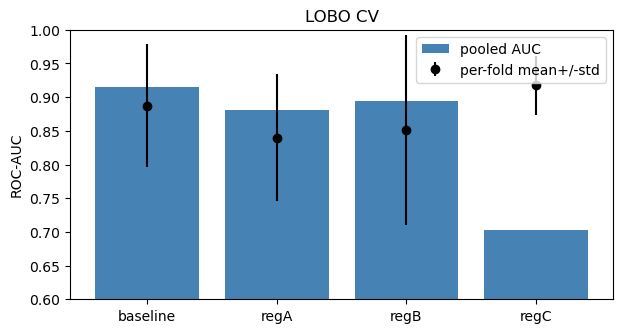

In [2]:
p = MODELS / 'lobo_cv_metrics.csv'
lobo = pd.read_csv(p) if p.exists() else pd.DataFrame()
display(lobo)
if not lobo.empty:
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.bar(lobo.config, lobo.pooled_auc, color='steelblue', label='pooled AUC')
    ax.errorbar(lobo.config, lobo.fold_auc_mean, yerr=lobo.fold_auc_std, fmt='o', color='k',
                label='per-fold mean+/-std')
    ax.set_ylabel('ROC-AUC'); ax.set_ylim(0.6, 1.0); ax.set_title('LOBO CV'); ax.legend(); plt.show()

### ROC / PR for the regA combined model (held-out outlets)

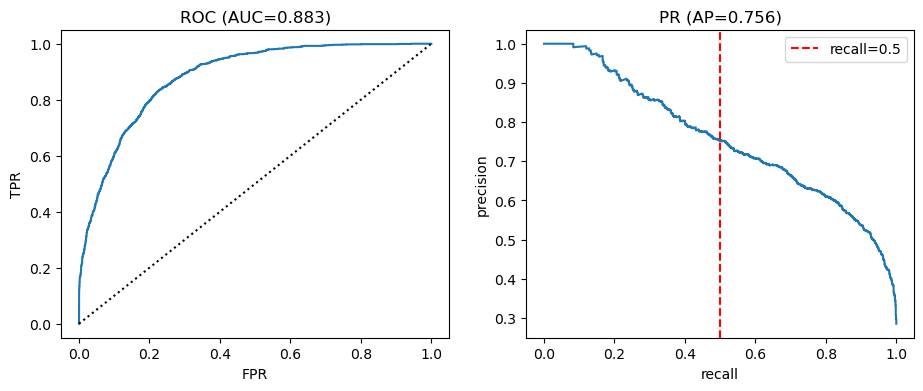

In [3]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score, average_precision_score
from xgboost import XGBClassifier
d = pd.read_csv(RESULTS_DIR / 'master_dataset_regA_with_emb.csv')
feats = MODEL_FEATURES + [f'emb_{i}' for i in range(4)]
d['grp'] = d.basin.astype(str) + '__' + d.outlet.astype(str)
tr, te = next(GroupShuffleSplit(1, test_size=0.2, random_state=42).split(d, d.y, d.grp))
mdl = XGBClassifier(); mdl.load_model(str(MODELS / 'xgb_geom_plus_cnn_emb_regA.json'))
proba = mdl.predict_proba(d.iloc[te][feats].to_numpy())[:, 1]; y = d.iloc[te].y.to_numpy()
fig, axs = plt.subplots(1, 2, figsize=(11, 4))
fpr, tpr, _ = roc_curve(y, proba); axs[0].plot(fpr, tpr); axs[0].plot([0,1],[0,1],'k:')
axs[0].set_title(f'ROC (AUC={roc_auc_score(y,proba):.3f})'); axs[0].set_xlabel('FPR'); axs[0].set_ylabel('TPR')
pr, rc, _ = precision_recall_curve(y, proba); axs[1].plot(rc, pr)
axs[1].axvline(0.5, color='r', ls='--', label='recall=0.5'); axs[1].legend()
axs[1].set_title(f'PR (AP={average_precision_score(y,proba):.3f})'); axs[1].set_xlabel('recall'); axs[1].set_ylabel('precision')
plt.show()

In [4]:
print('Operating thresholds (max-precision @ recall>=0.5), used for Mars:')
for r in REGIMES_:
    t = MODELS / f'optimal_threshold_geom_plus_cnn_emb_{r}.txt'
    if t.exists(): print(f'  {r}: {t.read_text().split()[0]}')

Operating thresholds (max-precision @ recall>=0.5), used for Mars:
  regA: 0.756326
  regB: 0.779264
  regC: 0.759369


**Mars caveat:** the Earth F1 threshold (0.577 for production) is tuned to Earth's
base rate. Mars has no labels, so we do not copy it — we carry the precision-oriented
point and study sensitivity in Stage 12. Deep dives:
`notebooks/diagnostics/lobo_cv.ipynb`, `notebooks/regime/02_threshold_retune.ipynb`.